In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sunraster.instr.spice import read_spice_l2_fits
import h5py
import sunpy 
import sunpy.map
from sharpesst.correct_2d_psf import get_fwd_matrices, correct_spice_raster
from sharpesst.util import bindown, as_dict, get_iris_data, masked_median_filter, get_mask_errs
from sharpesst.fit_spice_lines import get_overall_center, fit_spice_lines as fsl
import astropy
from astropy.visualization import (ImageNormalize, AsinhStretch)
from astropy import constants as const
import astropy.units as u
from astropy.io import fits
from astropy.wcs import WCS
import juanfit
import importlib
importlib.reload(juanfit)
from juanfit import SpectrumFit2D, gaussian, SpectrumFitSingle
from scipy.signal import find_peaks
from sospice import spice_error
from scipy.optimize import curve_fit

from copy import deepcopy
from glob import glob
from scipy.interpolate import RegularGridInterpolator

In [2]:
! module list


Currently Loaded Modules:
  1) eth_proxy       3) gcc/12.2.0    5) texlive/20220321
  2) stack/2024-06   4) cuda/12.4.1   6) ffmpeg/6.0

Inactive Modules:
  1) python/3.11.6_cuda   2) code-server/4.12.0

 



In [3]:
raster_files = sorted(glob("../../src/full_detector/level2/2022/10/24/*.fits"))
raster_files

['../../src/full_detector/level2/2022/10/24/solo_L2_spice-n-exp_20221024T221629_V04_150995397-000.fits',
 '../../src/full_detector/level2/2022/10/24/solo_L2_spice-n-exp_20221024T221815_V04_150995397-001.fits',
 '../../src/full_detector/level2/2022/10/24/solo_L2_spice-n-exp_20221024T222001_V04_150995397-002.fits',
 '../../src/full_detector/level2/2022/10/24/solo_L2_spice-n-exp_20221024T222148_V04_150995397-003.fits',
 '../../src/full_detector/level2/2022/10/24/solo_L2_spice-n-exp_20221024T222334_V04_150995397-004.fits',
 '../../src/full_detector/level2/2022/10/24/solo_L2_spice-n-exp_20221024T222519_V04_150995397-005.fits',
 '../../src/full_detector/level2/2022/10/24/solo_L2_spice-n-exp_20221024T222705_V04_150995397-006.fits',
 '../../src/full_detector/level2/2022/10/24/solo_L2_spice-n-exp_20221024T222851_V04_150995397-007.fits',
 '../../src/full_detector/level2/2022/10/24/solo_L2_spice-n-exp_20221024T223037_V04_150995397-008.fits',
 '../../src/full_detector/level2/2022/10/24/solo_L2_spi

In [4]:
test_raster_cube = read_spice_l2_fits(raster_files[0])

keyword looks very much like CROTAn but isn't. [astropy.wcs.wcs]
2025-03-04 12:43:39 - astropy - WARNING: FITSFixedWarning: CROTA = 4.74638738770 / [deg] S/C counter-clockwise roll rel to Solar N
keyword looks very much like CROTAn but isn't.
Set MJD-OBS to 59876.928116 from DATE-OBS.
Set MJD-BEG to 59876.928116 from DATE-BEG.
Set MJD-AVG to 59876.928461 from DATE-AVG.
Set MJD-END to 59876.928806 from DATE-END'. [astropy.wcs.wcs]
2025-03-04 12:43:39 - astropy - WARNING: FITSFixedWarning: 'datfix' made the change 'Set MJDREF to 59876.928116 from DATEREF.
Set MJD-OBS to 59876.928116 from DATE-OBS.
Set MJD-BEG to 59876.928116 from DATE-BEG.
Set MJD-AVG to 59876.928461 from DATE-AVG.
Set MJD-END to 59876.928806 from DATE-END'.
2025-03-04 12:43:39 - astropy - WARNING: UnitsWarning: 'W/m2/sr/nm' contains multiple slashes, which is discouraged by the FITS standard


In [5]:
test_raster_cube.keys()

dict_keys(['Full SW 4:1 Focal Lossy', 'Full LW 4:1 Focal Lossy'])

In [6]:
test_raster_cube['Full SW 4:1 Focal Lossy'].data.shape

(1, 1024, 1024, 1)

In [7]:
sw_data = np.ones((test_raster_cube['Full SW 4:1 Focal Lossy'].data.shape[1],
                   test_raster_cube['Full SW 4:1 Focal Lossy'].data.shape[2],
                   len(raster_files)))*np.nan

lw_data = np.ones((test_raster_cube['Full LW 4:1 Focal Lossy'].data.shape[1],
                     test_raster_cube['Full LW 4:1 Focal Lossy'].data.shape[2],
                     len(raster_files)))*np.nan

sw_wcs_list = []
lw_wcs_list = []
sw_meta_list = []
lw_meta_list = []
sw_wvl_list = []
lw_wvl_list = []

for ii, file_ in enumerate(raster_files):
    datacube_ = read_spice_l2_fits(file_)
    sw_data[:,:,ii] = datacube_['Full SW 4:1 Focal Lossy'].data[0,:,:,0]
    lw_data[:,:,ii] = datacube_['Full LW 4:1 Focal Lossy'].data[0,:,:,0]
    sw_wcs_list.append(datacube_['Full SW 4:1 Focal Lossy'].wcs)
    lw_wcs_list.append(datacube_['Full LW 4:1 Focal Lossy'].wcs)
    sw_meta_list.append(datacube_['Full SW 4:1 Focal Lossy'].meta)
    lw_meta_list.append(datacube_['Full LW 4:1 Focal Lossy'].meta)
    sw_wvl_list.append(datacube_['Full SW 4:1 Focal Lossy'].spectral_axis.to_value(u.AA))
    lw_wvl_list.append(datacube_['Full LW 4:1 Focal Lossy'].spectral_axis.to_value(u.AA))
sw_data = np.flip(sw_data, axis=-1)
lw_data = np.flip(lw_data, axis=-1)

keyword looks very much like CROTAn but isn't. [astropy.wcs.wcs]
2025-03-04 12:43:40 - astropy - WARNING: FITSFixedWarning: CROTA = 4.74580365575 / [deg] S/C counter-clockwise roll rel to Solar N
keyword looks very much like CROTAn but isn't.
Set MJD-OBS to 59876.929352 from DATE-OBS.
Set MJD-BEG to 59876.929352 from DATE-BEG.
Set MJD-AVG to 59876.929697 from DATE-AVG.
Set MJD-END to 59876.930042 from DATE-END'. [astropy.wcs.wcs]
2025-03-04 12:43:40 - astropy - WARNING: FITSFixedWarning: 'datfix' made the change 'Set MJDREF to 59876.929352 from DATEREF.
Set MJD-OBS to 59876.929352 from DATE-OBS.
Set MJD-BEG to 59876.929352 from DATE-BEG.
Set MJD-AVG to 59876.929697 from DATE-AVG.
Set MJD-END to 59876.930042 from DATE-END'.
keyword looks very much like CROTAn but isn't. [astropy.wcs.wcs]
2025-03-04 12:43:41 - astropy - WARNING: FITSFixedWarning: CROTA = 4.74521961614 / [deg] S/C counter-clockwise roll rel to Solar N
keyword looks very much like CROTAn but isn't.
Set MJD-OBS to 59876.930

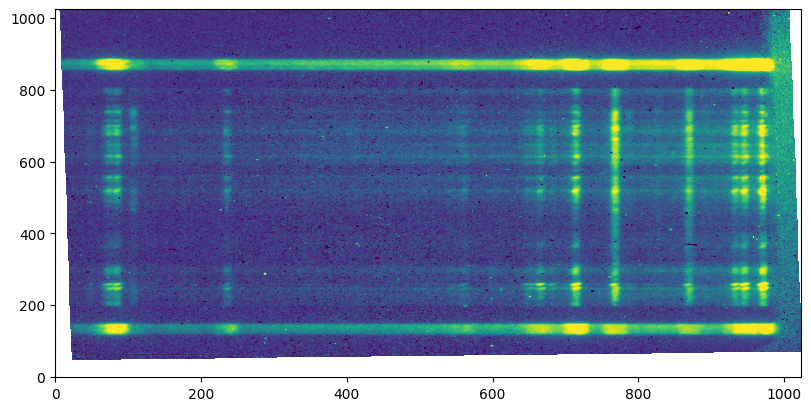

In [8]:
fig, ax = plt.subplots(figsize=(8,4),layout="constrained")
ax.imshow(sw_data[:,:,0].T, origin='lower',
          norm=ImageNormalize(vmin=np.nanpercentile(sw_data[:,:,0], 1),
                                vmax=np.nanpercentile(sw_data[:,:,0], 99),
                                stretch=AsinhStretch()),
                                aspect='auto')

/scratch/tmp.25099103.zhuyin/ipykernel_667000/1735943025.py:2: RuntimeWarning: Mean of empty slice
  ax.step(sw_wvl_list[0], np.nanmean(sw_data[:,210:790,0], axis=1), where='mid')


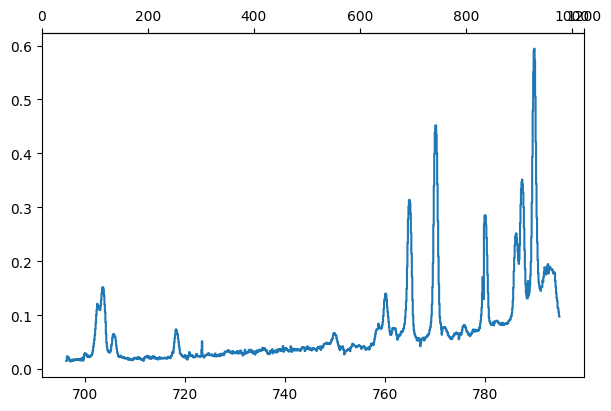

In [9]:
fig, ax = plt.subplots(figsize=(6,4),layout="constrained")
ax.step(sw_wvl_list[0], np.nanmean(sw_data[:,210:790,0], axis=1), where='mid')

def forward(x):
    return np.interp(x, sw_wvl_list[0], np.arange(sw_data.shape[0]))

def inverse(x):
    return np.interp(x, np.arange(sw_data.shape[0]), sw_wvl_list[0])

secax = ax.secondary_xaxis('top', functions=(forward, inverse))

/scratch/tmp.25099103.zhuyin/ipykernel_667000/2634672493.py:2: RuntimeWarning: Mean of empty slice
  ax.step(sw_wvl_list[0], np.nanmean(sw_data[:,210:790,0], axis=1), where='mid')


(0.05, 0.6)

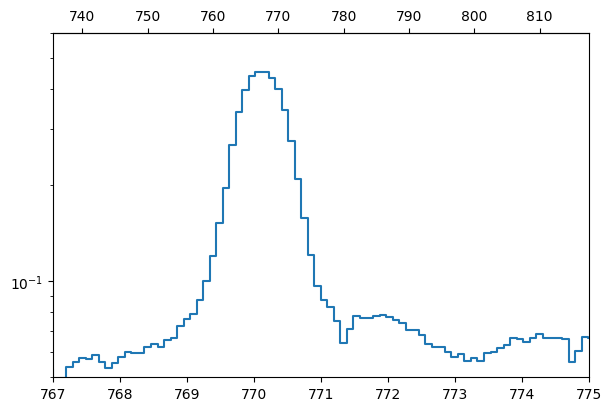

In [10]:
fig, ax = plt.subplots(figsize=(6,4),layout="constrained")
ax.step(sw_wvl_list[0], np.nanmean(sw_data[:,210:790,0], axis=1), where='mid')

def forward(x):
    return np.interp(x, sw_wvl_list[0], np.arange(sw_data.shape[0]))

def inverse(x):
    return np.interp(x, np.arange(sw_data.shape[0]), sw_wvl_list[0])

secax = ax.secondary_xaxis('top', functions=(forward, inverse))
# _ = secax.set_xticks([0,200,400,600,800,1000])

ax.set_xlim(767,775)
ax.set_yscale("log")
ax.set_ylim(5e-2,0.6)

Ne VIII 780 is blended with two O IV lines at the blue wing

/scratch/tmp.25099103.zhuyin/ipykernel_667000/4116573967.py:2: RuntimeWarning: Mean of empty slice
  ax.step(sw_wvl_list[0], np.nanmean(sw_data[:,210:790,0], axis=1), where='mid')


(779.0, 781.0)

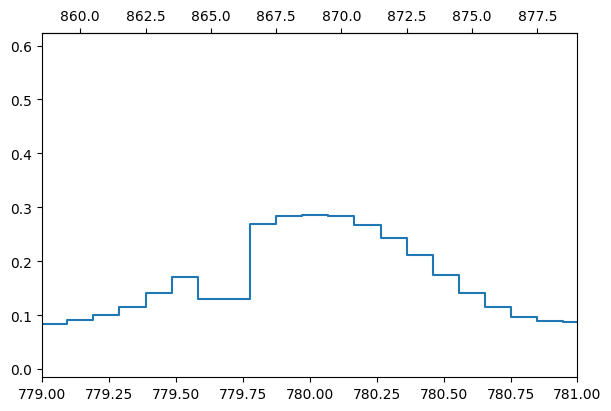

In [11]:
fig, ax = plt.subplots(figsize=(6,4),layout="constrained")
ax.step(sw_wvl_list[0], np.nanmean(sw_data[:,210:790,0], axis=1), where='mid')

def forward(x):
    return np.interp(x, sw_wvl_list[0], np.arange(sw_data.shape[0]))

def inverse(x):
    return np.interp(x, np.arange(sw_data.shape[0]), sw_wvl_list[0])

secax = ax.secondary_xaxis('top', functions=(forward, inverse))
# _ = secax.set_xticks([0,200,400,600,800,1000])

ax.set_xlim(779,781)

N IV 765 has two N III blending at the blue wing (763.334, 764.351)

/scratch/tmp.25099103.zhuyin/ipykernel_667000/3505017448.py:2: RuntimeWarning: Mean of empty slice
  ax.step(sw_wvl_list[0], np.nanmean(sw_data[:,210:790,0], axis=1), where='mid')


(0.03, 0.5)

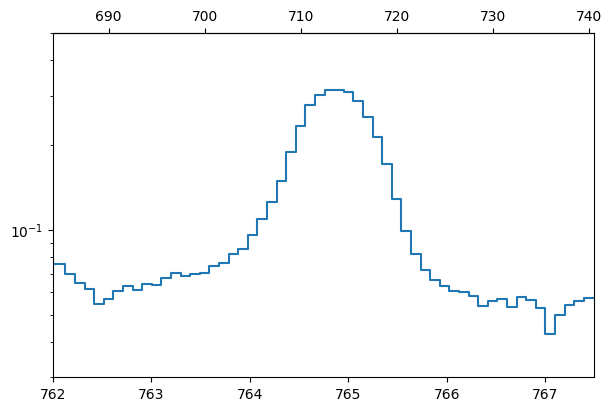

In [12]:
fig, ax = plt.subplots(figsize=(6,4),layout="constrained")
ax.step(sw_wvl_list[0], np.nanmean(sw_data[:,210:790,0], axis=1), where='mid')

def forward(x):
    return np.interp(x, sw_wvl_list[0], np.arange(sw_data.shape[0]))

def inverse(x):
    return np.interp(x, np.arange(sw_data.shape[0]), sw_wvl_list[0])

secax = ax.secondary_xaxis('top', functions=(forward, inverse))
# _ = secax.set_xticks([0,200,400,600,800,1000])

ax.set_xlim(762,767.5)
ax.set_yscale("log")
ax.set_ylim(3e-2, 0.5)

In [13]:
print(770.428 - 769.355)
print(770.428 - 772.260)

1.072999999999979
-1.8319999999999936


In [14]:
def func_NeVIII_770(x, wvl_770, int_769, int_770, int_772, wid_770, wid_772, a, b):
    return gaussian(x, wvl_770-1.073, int_769, wid_772) + \
           gaussian(x, wvl_770, int_770, wid_770) + \
           gaussian(x, wvl_770+1.832, int_772, wid_772) + \
           a*x + b

In [15]:
test_fit_NeVIII_wvl = sw_wvl_list[0][735:799]
test_fit_NeVIII_data = np.nanmean(sw_data[:,210:790,-1], axis=1)[735:799]

/scratch/tmp.25099103.zhuyin/ipykernel_667000/201903167.py:2: RuntimeWarning: Mean of empty slice
  test_fit_NeVIII_data = np.nanmean(sw_data[:,210:790,-1], axis=1)[735:799]


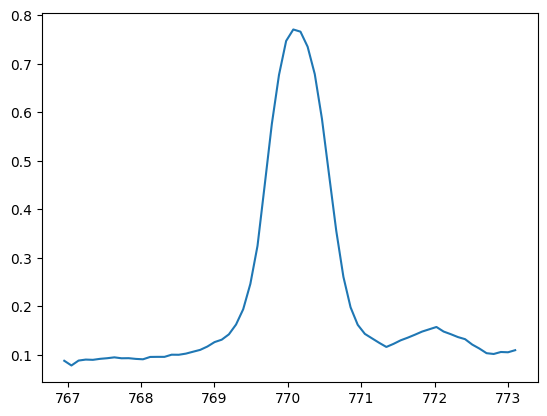

In [16]:
plt.plot(test_fit_NeVIII_wvl, test_fit_NeVIII_data)

In [17]:
test_fit_NeVIII_model = SpectrumFitSingle(data=test_fit_NeVIII_data,
                                        wvl=test_fit_NeVIII_wvl,
                                        err=None,
                                        custom_func=func_NeVIII_770,
                                        custom_init=[770.428, 0.1, 0.4, 0.1, 0.7, 0.7, 0, 0.5],)

test_fit_NeVIII_model.run_lse()

/cluster/home/zhuyin/scripts/MyPy/juanfit.py:235: UserWarning: No input errors, absolute_sigma=False will be used in the Chi2 fitting.
  warn("No input errors, absolute_sigma=False will be used in the Chi2 fitting.")


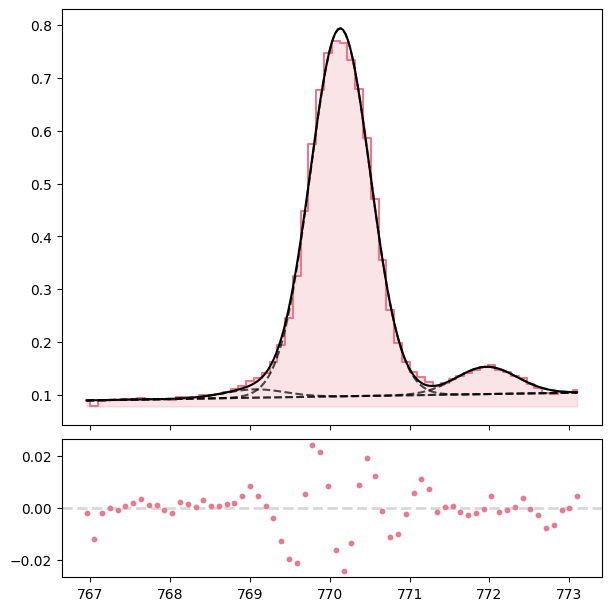

In [18]:
fig, (ax1,ax2) = plt.subplots(2,1,figsize=(6,6), layout="constrained",
                            gridspec_kw={'height_ratios': [3,1]}, sharex=True)

test_fit_NeVIII_wvl_plot = np.linspace(test_fit_NeVIII_wvl[0], test_fit_NeVIII_wvl[-1], 200)

ax1.step(test_fit_NeVIII_wvl, test_fit_NeVIII_data, where='mid', color="#E87A90")
ax1.fill_between(test_fit_NeVIII_wvl, np.nanmin(test_fit_NeVIII_data), test_fit_NeVIII_data, color="#E87A90", alpha=0.2)
ax1.plot(test_fit_NeVIII_wvl_plot, func_NeVIII_770(test_fit_NeVIII_wvl_plot, *test_fit_NeVIII_model.custom_fit),
        color="black")

ax1.plot(test_fit_NeVIII_wvl_plot, test_fit_NeVIII_model.custom_fit[6]*test_fit_NeVIII_wvl_plot + test_fit_NeVIII_model.custom_fit[7],
        color="grey", linestyle="dashed")

ax1.plot(test_fit_NeVIII_wvl_plot, gaussian(test_fit_NeVIII_wvl_plot, test_fit_NeVIII_model.custom_fit[0]-1.073,
                                           test_fit_NeVIII_model.custom_fit[1],
                                           test_fit_NeVIII_model.custom_fit[5]) + \
         test_fit_NeVIII_model.custom_fit[6]*test_fit_NeVIII_wvl_plot + test_fit_NeVIII_model.custom_fit[7],
        color="black", linestyle="dashed", alpha=0.7)

ax1.plot(test_fit_NeVIII_wvl_plot, gaussian(test_fit_NeVIII_wvl_plot, test_fit_NeVIII_model.custom_fit[0],
                                           test_fit_NeVIII_model.custom_fit[2],
                                           test_fit_NeVIII_model.custom_fit[4]) + \
         test_fit_NeVIII_model.custom_fit[6]*test_fit_NeVIII_wvl_plot + test_fit_NeVIII_model.custom_fit[7],
        color="black", linestyle="dashed", alpha=0.7)

ax1.plot(test_fit_NeVIII_wvl_plot, gaussian(test_fit_NeVIII_wvl_plot, test_fit_NeVIII_model.custom_fit[0]+1.832,
                                           test_fit_NeVIII_model.custom_fit[3],
                                           test_fit_NeVIII_model.custom_fit[5]) + \
         test_fit_NeVIII_model.custom_fit[6]*test_fit_NeVIII_wvl_plot + test_fit_NeVIII_model.custom_fit[7],
        color="black", linestyle="dashed", alpha=0.7)

ax2.scatter(test_fit_NeVIII_wvl, test_fit_NeVIII_data - func_NeVIII_770(test_fit_NeVIII_wvl, *test_fit_NeVIII_model.custom_fit),
            s=10, color="#E87A90")
ax2.axhline(0, color="grey", lw=2, ls="--", alpha=0.3, zorder=0)

In [19]:
def double_gaussian(x, line_wvl, int_total, fwhm, alpha, beta):
    return gaussian(x, line_wvl, int_total, fwhm) + \
    gaussian(x, line_wvl, alpha*int_total, beta*fwhm)

def func_NeVIII_770_dg(x, wvl_770, int_769, int_770, int_772,
                       wid_770, wid_772,
                       a, b, alpha, beta):
    return double_gaussian(x, wvl_770-1.073, int_769, wid_772, alpha, beta) + \
           double_gaussian(x, wvl_770, int_770, wid_770, alpha, beta) + \
           double_gaussian(x, wvl_770+1.832, int_772, wid_772, alpha, beta) + \
           a*x + b

In [20]:
test_fit_NeVIII_dg_model = SpectrumFitSingle(wvl=test_fit_NeVIII_wvl,
                                        data=test_fit_NeVIII_data,
                                        custom_func=func_NeVIII_770_dg,
                                        custom_init=[*test_fit_NeVIII_model.custom_fit, 1e-2,1e-1],
                                        err=None)

test_fit_NeVIII_dg_model.run_lse()

In [21]:
print(f"Ne VIII 770 wvl: {test_fit_NeVIII_dg_model.custom_fit[0]:.3f}",
      f"Mg VIII 769 wvl: {test_fit_NeVIII_dg_model.custom_fit[0] - 1.073:.3f}", 
      f"Mg VIII 772 wvl: {test_fit_NeVIII_dg_model.custom_fit[0] + 1.832:.3f}",
      f"Ne VIII 770 vel: {(test_fit_NeVIII_dg_model.custom_fit[0]/770.428 - 1)*const.c.to_value(u.km/u.s):.1f}",
      f"Mg VIII 769 vel: {((test_fit_NeVIII_dg_model.custom_fit[0] - 1.073)/769.355 - 1)*const.c.to_value(u.km/u.s):.1f}",
      f"Mg VIII 772 vel: {((test_fit_NeVIII_dg_model.custom_fit[0] + 1.832)/772.260 - 1)*const.c.to_value(u.km/u.s):.1f}",
      f"Ne VIII 770 int: {test_fit_NeVIII_dg_model.custom_fit[2]:.3f}",
      f"Mg VIII 769 int: {test_fit_NeVIII_dg_model.custom_fit[1]:.3f}",
      f"Mg VIII 772 int: {test_fit_NeVIII_dg_model.custom_fit[3]:.3f}",
      f"Ne VIII 770 FWHM: {test_fit_NeVIII_dg_model.custom_fit[4]:.3f}",
      f"Mg VIII FWHM: {test_fit_NeVIII_dg_model.custom_fit[5]:.3f}",
      f"Continuum Slope: {test_fit_NeVIII_dg_model.custom_fit[6]:.3e}",
      f"Continuum Intercept: {test_fit_NeVIII_dg_model.custom_fit[7]:.3f}",
      f"Secondary Gaussian Intensity Ratio {test_fit_NeVIII_dg_model.custom_fit[8]:.3f}",
      f"Secondary Gaussian FWHM Ratio {test_fit_NeVIII_dg_model.custom_fit[9]:.3f}",
      sep="\n")

Ne VIII 770 wvl: 770.132
Mg VIII 769 wvl: 769.059
Mg VIII 772 wvl: 771.964
Ne VIII 770 vel: -115.4
Mg VIII 769 vel: -115.5
Mg VIII 772 vel: -115.1
Ne VIII 770 int: 0.684
Mg VIII 769 int: 0.019
Mg VIII 772 int: 0.044
Ne VIII 770 FWHM: 0.831
Mg VIII FWHM: 0.783
Continuum Slope: 3.313e-03
Continuum Intercept: -2.452
Secondary Gaussian Intensity Ratio -0.059
Secondary Gaussian FWHM Ratio 0.437


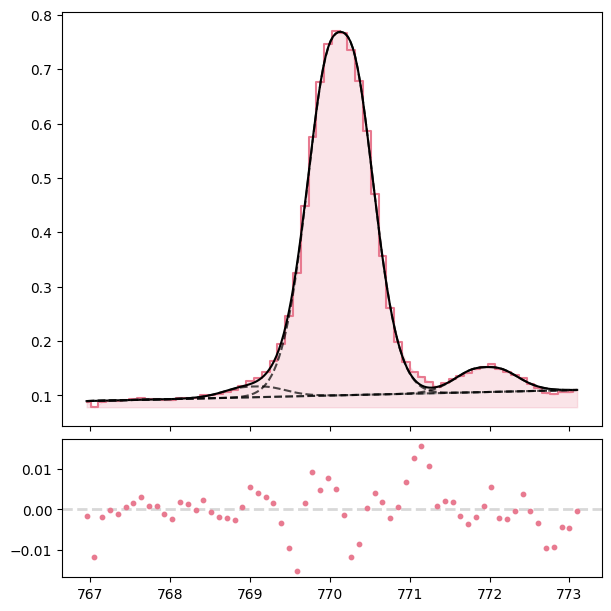

In [22]:
fig, (ax1,ax2) = plt.subplots(2,1,figsize=(6,6), layout="constrained",
                            gridspec_kw={'height_ratios': [3,1]}, sharex=True)

ax1.step(test_fit_NeVIII_wvl, test_fit_NeVIII_data, where='mid', color="#E87A90")
ax1.fill_between(test_fit_NeVIII_wvl, np.nanmin(test_fit_NeVIII_data), test_fit_NeVIII_data, color="#E87A90", alpha=0.2)

ax1.plot(test_fit_NeVIII_wvl_plot, func_NeVIII_770_dg(test_fit_NeVIII_wvl_plot, *test_fit_NeVIII_dg_model.custom_fit),
        color="black")

ax1.plot(test_fit_NeVIII_wvl_plot, test_fit_NeVIII_dg_model.custom_fit[6]*test_fit_NeVIII_wvl_plot + test_fit_NeVIII_dg_model.custom_fit[7],
        color="grey", linestyle="dashed")

ax1.plot(test_fit_NeVIII_wvl_plot, double_gaussian(test_fit_NeVIII_wvl_plot, test_fit_NeVIII_dg_model.custom_fit[0]-1.073,
                                           test_fit_NeVIII_dg_model.custom_fit[1],
                                           test_fit_NeVIII_dg_model.custom_fit[5],
                                           test_fit_NeVIII_dg_model.custom_fit[8],
                                           test_fit_NeVIII_dg_model.custom_fit[9]) + \
         test_fit_NeVIII_dg_model.custom_fit[6]*test_fit_NeVIII_wvl_plot + test_fit_NeVIII_dg_model.custom_fit[7],
        color="black", linestyle="dashed", alpha=0.7)

ax1.plot(test_fit_NeVIII_wvl_plot, double_gaussian(test_fit_NeVIII_wvl_plot, test_fit_NeVIII_dg_model.custom_fit[0],
                                           test_fit_NeVIII_dg_model.custom_fit[2],
                                           test_fit_NeVIII_dg_model.custom_fit[4],
                                           test_fit_NeVIII_dg_model.custom_fit[8],
                                           test_fit_NeVIII_dg_model.custom_fit[9]) + \
         test_fit_NeVIII_dg_model.custom_fit[6]*test_fit_NeVIII_wvl_plot + test_fit_NeVIII_dg_model.custom_fit[7],
        color="black", linestyle="dashed", alpha=0.7)

ax1.plot(test_fit_NeVIII_wvl_plot, double_gaussian(test_fit_NeVIII_wvl_plot, test_fit_NeVIII_dg_model.custom_fit[0]+1.832,
                                           test_fit_NeVIII_dg_model.custom_fit[3],
                                           test_fit_NeVIII_dg_model.custom_fit[5],
                                           test_fit_NeVIII_dg_model.custom_fit[8],
                                           test_fit_NeVIII_dg_model.custom_fit[9]) + \
         test_fit_NeVIII_dg_model.custom_fit[6]*test_fit_NeVIII_wvl_plot + test_fit_NeVIII_dg_model.custom_fit[7],
        color="black", linestyle="dashed", alpha=0.7)

ax2.scatter(test_fit_NeVIII_wvl, test_fit_NeVIII_data - func_NeVIII_770_dg(test_fit_NeVIII_wvl, *test_fit_NeVIII_dg_model.custom_fit),
            s=10, color="#E87A90")      
ax2.axhline(0, color="grey", lw=2, ls="--", alpha=0.3, zorder=0)

In [23]:
cdelt1 = np.sqrt(np.sum((sw_wcs_list[0].wcs.crval[:2] - sw_wcs_list[1].wcs.crval[:2])**2))*3600
cdelt1

3.523144994791964

In [24]:
cdelt2 = sw_wcs_list[0].wcs.cdelt[1]*3600
cdelt2

1.098

In [25]:
NeVIII_770_intmap = np.nanmean(sw_data[755:780,:,:], axis=0)
NIV_765_intmap = np.nanmean(sw_data[705:725,:,:], axis=0)

/scratch/tmp.25099103.zhuyin/ipykernel_667000/2019181606.py:1: RuntimeWarning: Mean of empty slice
  NeVIII_770_intmap = np.nanmean(sw_data[755:780,:,:], axis=0)
/scratch/tmp.25099103.zhuyin/ipykernel_667000/2019181606.py:2: RuntimeWarning: Mean of empty slice
  NIV_765_intmap = np.nanmean(sw_data[705:725,:,:], axis=0)


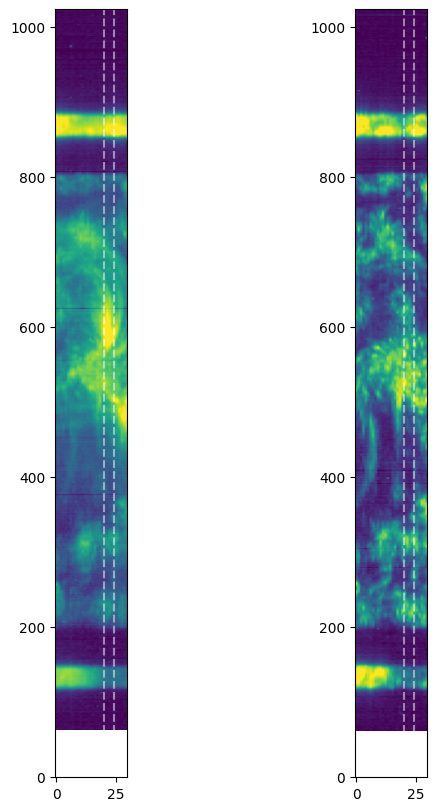

In [26]:
fig, (ax1,ax2) = plt.subplots(1,2, figsize=(6,8),layout="constrained")
ax1.imshow(NeVIII_770_intmap, origin='lower',
           norm=ImageNormalize(vmin=np.nanpercentile(NeVIII_770_intmap, 1),
                               vmax=np.nanpercentile(NeVIII_770_intmap, 99),
                               stretch=AsinhStretch()), aspect=cdelt2/cdelt1)

ax2.imshow(NIV_765_intmap, origin='lower',
              norm=ImageNormalize(vmin=np.nanpercentile(NIV_765_intmap, 1),
                                  vmax=np.nanpercentile(NIV_765_intmap, 99),
                                  stretch=AsinhStretch()), aspect=cdelt2/cdelt1)

for ax_ in (ax1,ax2):
    ax_.axvline(20, color='w', linestyle='--', alpha=0.5)
    ax_.axvline(24, color='w', linestyle='--', alpha=0.5)

In [27]:
test_column_data_20 = sw_data[:,210:790,20]
test_column_data_20_NeVIII = test_column_data_20[735:799,:]
test_column_data_20_NIV = test_column_data_20[685:740,:]

In [28]:
with fits.open(raster_files[-21]) as hdul:
    test_column_dark_20_all, test_column_dark_20_sigma = spice_error(hdul[0])

Getting observation parameters from Full SW 4:1 Focal Lossy

Slit: 4.0 arcsec
Bin: (1, 1)
Exposure time: 59.6 s
Window width: 1024.0 pix
Average wavelength: 74.515895 nm
RADCAL: 580.263480489 m2 ct nm sr / W
            


In [29]:
test_column_data_20_NeVIII_sigma = test_column_dark_20_sigma['Total'][0,735:799,210:790,0]
test_column_data_20_NIV_sigma = test_column_dark_20_sigma['Total'][0,685:740,210:790,0]

387
[315 327 330 339 354 369 375 377 382 387 391 402 412 417 426 429]


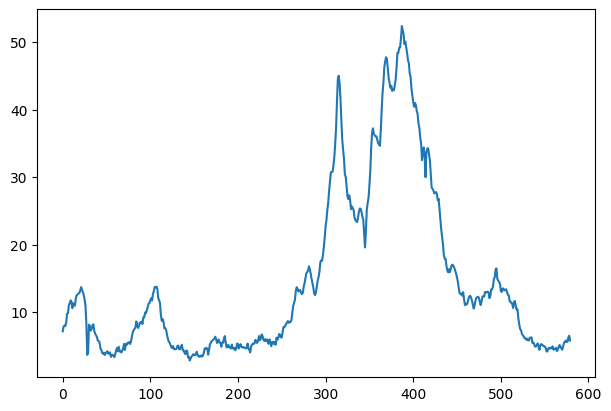

In [30]:
fig, ax = plt.subplots(figsize=(6,4),layout="constrained")
ax.plot(np.nansum(test_column_data_20_NeVIII, axis=0), label="Ne VIII")
print(np.nanargmax(np.nansum(test_column_data_20_NeVIII, axis=0)))
print(find_peaks(np.nansum(test_column_data_20_NeVIII, axis=0), height=25)[0])

In [31]:
test_NeVIII_data_315 = np.nanmean(test_column_data_20_NeVIII[:, 315-2:315+3], axis=1)
test_NeVIII_err_315 = np.sqrt(np.nansum(test_column_data_20_NeVIII_sigma[:, 315-2:315+3]**2, axis=1))/5
test_NeVIII_err_315 = test_NeVIII_err_315.to_value()
test_NeVIII_data_387 = np.nanmean(test_column_data_20_NeVIII[:, 387-2:387+3], axis=1)
test_NeVIII_err_387 = np.sqrt(np.nansum(test_column_data_20_NeVIII_sigma[:, 387-2:387+3]**2, axis=1))/5
test_NeVIII_err_387 = test_NeVIII_err_387.to_value()

<ErrorbarContainer object of 3 artists>

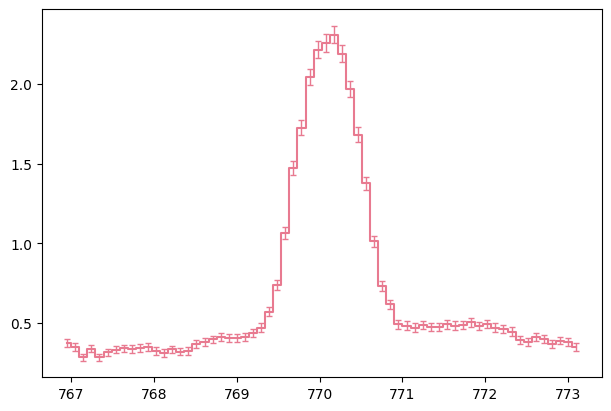

In [32]:
fig, ax = plt.subplots(figsize=(6,4),layout="constrained")
ax.errorbar(test_fit_NeVIII_wvl, test_NeVIII_data_315, test_NeVIII_err_315,
            color="#E87A90", label="Ne VIII", elinewidth=1, capsize=2, capthick=1,
            ds="steps-mid")

<ErrorbarContainer object of 3 artists>

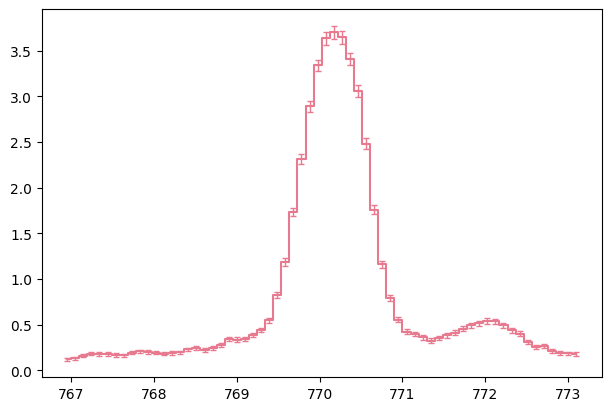

In [33]:
fig, ax = plt.subplots(figsize=(6,4),layout="constrained")
ax.errorbar(test_fit_NeVIII_wvl, test_NeVIII_data_387, test_NeVIII_err_387,
            color="#E87A90", label="Ne VIII", elinewidth=1, capsize=2, capthick=1,
            ds="steps-mid")

In [34]:
test_fit_NeVIII_sg_model_387 = SpectrumFitSingle(wvl=test_fit_NeVIII_wvl,
                                data=test_NeVIII_data_387,
                                err=test_NeVIII_err_387,
                                custom_func=func_NeVIII_770,
                                custom_init=[test_fit_NeVIII_wvl[np.nanargmax(test_NeVIII_data_387)],
                                            0.2, 3, 0.2, 0.7, 0.7, 0, 0.2],
                                )
test_fit_NeVIII_sg_model_387.run_lse()

<ErrorbarContainer object of 3 artists>

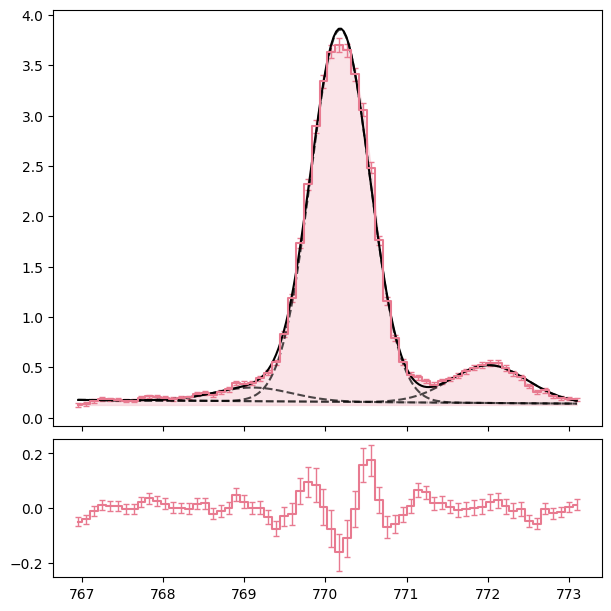

In [35]:
fig, (ax1,ax2) = plt.subplots(2,1,figsize=(6,6),layout="constrained",
                        gridspec_kw={'height_ratios': [3,1]}, sharex=True)
ax1.errorbar(test_fit_NeVIII_wvl, test_NeVIII_data_387, test_NeVIII_err_387,
            color="#E87A90", label="Ne VIII", elinewidth=1, capsize=2, capthick=1,
            ds="steps-mid")
ax1.fill_between(test_fit_NeVIII_wvl, np.nanmin(test_NeVIII_data_387), test_NeVIII_data_387, color="#E87A90", alpha=0.2)

ax1.plot(test_fit_NeVIII_wvl_plot, func_NeVIII_770(test_fit_NeVIII_wvl_plot, *test_fit_NeVIII_sg_model_387.custom_fit),
        color="black")

ax1.plot(test_fit_NeVIII_wvl_plot, test_fit_NeVIII_sg_model_387.custom_fit[6]*test_fit_NeVIII_wvl_plot + test_fit_NeVIII_sg_model_387.custom_fit[7],
        color="black", linestyle="dashed", alpha=0.3)

ax1.plot(test_fit_NeVIII_wvl_plot, gaussian(test_fit_NeVIII_wvl_plot, test_fit_NeVIII_sg_model_387.custom_fit[0],
                                           test_fit_NeVIII_sg_model_387.custom_fit[2],
                                           test_fit_NeVIII_sg_model_387.custom_fit[4]) + \
         test_fit_NeVIII_sg_model_387.custom_fit[6]*test_fit_NeVIII_wvl_plot + test_fit_NeVIII_sg_model_387.custom_fit[7],
        color="black", linestyle="dashed", alpha=0.7)

ax1.plot(test_fit_NeVIII_wvl_plot, gaussian(test_fit_NeVIII_wvl_plot, test_fit_NeVIII_sg_model_387.custom_fit[0] - 1.073,
                                           test_fit_NeVIII_sg_model_387.custom_fit[1],
                                           test_fit_NeVIII_sg_model_387.custom_fit[5]) + \
         test_fit_NeVIII_sg_model_387.custom_fit[6]*test_fit_NeVIII_wvl_plot + test_fit_NeVIII_sg_model_387.custom_fit[7],
        color="black", linestyle="dashed", alpha=0.7)

ax1.plot(test_fit_NeVIII_wvl_plot, gaussian(test_fit_NeVIII_wvl_plot, test_fit_NeVIII_sg_model_387.custom_fit[0] + 1.832,
                                           test_fit_NeVIII_sg_model_387.custom_fit[3],
                                           test_fit_NeVIII_sg_model_387.custom_fit[5]) + \
         test_fit_NeVIII_sg_model_387.custom_fit[6]*test_fit_NeVIII_wvl_plot + test_fit_NeVIII_sg_model_387.custom_fit[7],
        color="black", linestyle="dashed", alpha=0.7)

ax2.errorbar(test_fit_NeVIII_wvl, test_NeVIII_data_387 - func_NeVIII_770(test_fit_NeVIII_wvl, *test_fit_NeVIII_sg_model_387.custom_fit),
            test_NeVIII_err_387, color="#E87A90", elinewidth=1, capsize=2, capthick=1,
            ds="steps-mid")

In [36]:
test_fit_NeVIII_sg_model_387.custom_fit

array([ 7.70183065e+02,  1.62307567e-01,  3.37459320e+00,  4.48541066e-01,
        8.57250252e-01,  1.12174169e+00, -5.96520030e-03,  4.75008876e+00])

In [37]:
popt, pcov = curve_fit(func_NeVIII_770_dg, test_fit_NeVIII_wvl, test_NeVIII_data_387,
        sigma=test_NeVIII_err_387,
        p0=[test_fit_NeVIII_sg_model_387.custom_fit[0],
            *test_fit_NeVIII_sg_model_387.custom_fit[1:4]*0.8,
            0.8, 0.8, 0, 0.2 ,0.1, 1.5],
            bounds = (np.array([770.1, 0.071*0.5, 3.263*0.5, 0.315*0.5, 0.843*0.8, 0.914*0.5, -1e-2, -10, 0, 1]),
                      np.array([770.25,0.071*2, 3.263*1.5,   0.315*1.5, 0.843*1.2, 0.914*1.2,  1e-2,  10, 0.5, 6])),
            maxfev=100000)

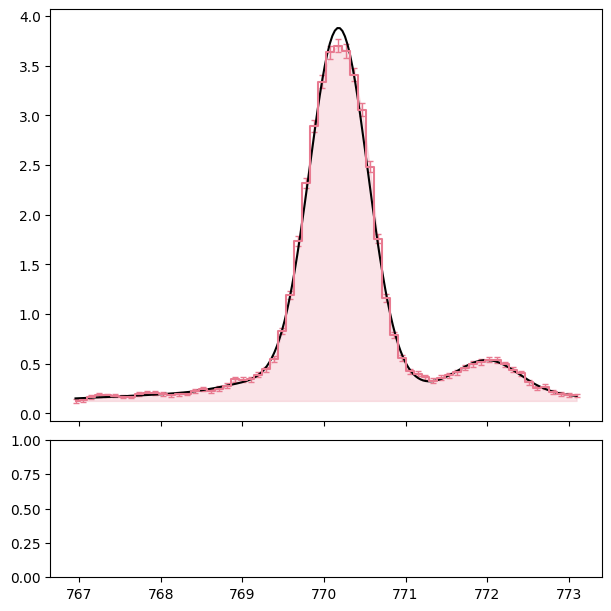

In [38]:
fig, (ax1,ax2) = plt.subplots(2,1,figsize=(6,6),layout="constrained",
                            gridspec_kw={'height_ratios': [3,1]}, sharex=True)

ax1.errorbar(test_fit_NeVIII_wvl, test_NeVIII_data_387, test_NeVIII_err_387,
            color="#E87A90", label="Ne VIII", elinewidth=1, capsize=2, capthick=1,
            ds="steps-mid")
ax1.fill_between(test_fit_NeVIII_wvl, np.nanmin(test_NeVIII_data_387), test_NeVIII_data_387, color="#E87A90", alpha=0.2)

ax1.plot(test_fit_NeVIII_wvl_plot, func_NeVIII_770_dg(test_fit_NeVIII_wvl_plot, *popt),
        color="black")

In [39]:
print(f"Ne VIII 770 wvl: {popt[0]:.3f}",
      f"Mg VIII 769 wvl: {popt[0] - 1.073:.3f}", 
      f"Mg VIII 772 wvl: {popt[0] + 1.832:.3f}",
      f"Ne VIII 770 vel: {(popt[0]/770.428 - 1)*const.c.to_value(u.km/u.s):.1f}",
      f"Mg VIII 769 vel: {((popt[0] - 1.073)/769.355 - 1)*const.c.to_value(u.km/u.s):.1f}",
      f"Mg VIII 772 vel: {((popt[0] + 1.832)/772.260 - 1)*const.c.to_value(u.km/u.s):.1f}",
      f"Ne VIII 770 int: {popt[2]:.3f}",
      f"Mg VIII 769 int: {popt[1]:.3f}",
      f"Mg VIII 772 int: {popt[3]:.3f}",
      f"Ne VIII 770 FWHM: {popt[4]:.3f}",
      f"Mg VIII FWHM: {popt[5]:.3f}",
      f"Continuum Slope: {popt[6]:.3e}",
      f"Continuum Intercept: {popt[7]:.3f}",
      f"Secondary Gaussian Intensity Ratio {popt[8]:.3f}",
      f"Secondary Gaussian FWHM Ratio {popt[9]:.3f}",
      sep="\n")

Ne VIII 770 wvl: 770.179
Mg VIII 769 wvl: 769.106
Mg VIII 772 wvl: 772.011
Ne VIII 770 vel: -96.8
Mg VIII 769 vel: -97.0
Mg VIII 772 vel: -96.6
Ne VIII 770 int: 3.241
Mg VIII 769 int: 0.068
Mg VIII 772 int: 0.310
Ne VIII 770 FWHM: 0.840
Mg VIII FWHM: 0.904
Continuum Slope: 5.499e-06
Continuum Intercept: 0.098
Secondary Gaussian Intensity Ratio 0.232
Secondary Gaussian FWHM Ratio 6.000


/scratch/tmp.25099103.zhuyin/ipykernel_667000/82616663.py:2: RuntimeWarning: Mean of empty slice
  ax.step(lw_wvl_list[0], np.nanmean(lw_data[:,210:790,0], axis=1), where='mid')


(0.01, 6)

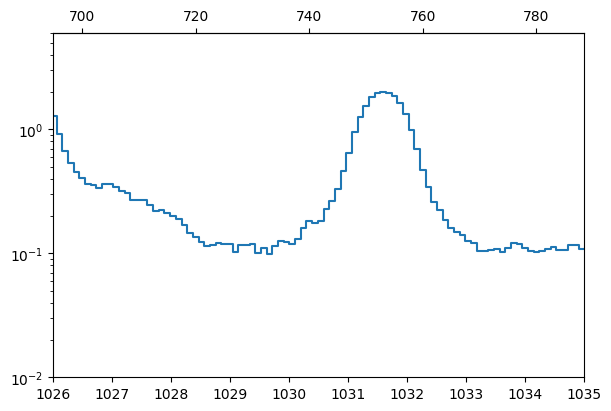

In [40]:
fig, ax = plt.subplots(figsize=(6,4),layout="constrained")
ax.step(lw_wvl_list[0], np.nanmean(lw_data[:,210:790,0], axis=1), where='mid')

def forward(x):
    return np.interp(x, lw_wvl_list[0], np.arange(lw_data.shape[0]))

def inverse(x):
    return np.interp(x, np.arange(lw_data.shape[0]), lw_wvl_list[0])

secax = ax.secondary_xaxis('top', functions=(forward, inverse))
# _ = secax.set_xticks([0,200,400,600,800,1000])

ax.set_yscale("log")

ax.set_xlim(1026,1035)
ax.set_ylim(1e-2, 6)

/scratch/tmp.25099103.zhuyin/ipykernel_667000/2554681085.py:2: RuntimeWarning: Mean of empty slice
  ax.step(lw_wvl_list[0], np.nanmean(lw_data[:,210:790,0], axis=1), where='mid')


(0.01, 6)

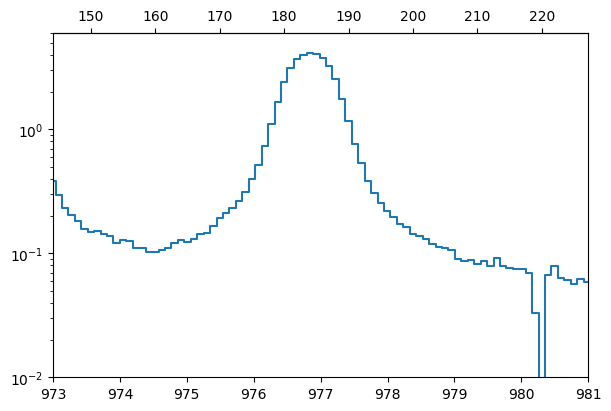

In [41]:
fig, ax = plt.subplots(figsize=(6,4),layout="constrained")
ax.step(lw_wvl_list[0], np.nanmean(lw_data[:,210:790,0], axis=1), where='mid')

def forward(x):
    return np.interp(x, lw_wvl_list[0], np.arange(lw_data.shape[0]))

def inverse(x):
    return np.interp(x, np.arange(lw_data.shape[0]), lw_wvl_list[0])

secax = ax.secondary_xaxis('top', functions=(forward, inverse))
# _ = secax.set_xticks([0,200,400,600,800,1000])

ax.set_yscale("log")

ax.set_xlim(973,981)
ax.set_ylim(1e-2, 6)

In [42]:
def func_CIII_977(x, wvl_977, int_977, wid_977, a, b):
    return gaussian(x, wvl_977, int_977, wid_977) + \
           a*x + b

In [43]:
CIII_977_data_all = lw_data[160:210,210:790,:]
CIII_977_wvl = lw_wvl_list[0][160:210]

In [44]:
CIII_977_fit_int = np.zeros(CIII_977_data_all.shape[1:])
CIII_977_fit_wvl = np.zeros(CIII_977_data_all.shape[1:])
CIII_977_fit_wid = np.zeros(CIII_977_data_all.shape[1:])
CIII_977_fit_a = np.zeros(CIII_977_data_all.shape[1:])
CIII_977_fit_b = np.zeros(CIII_977_data_all.shape[1:])

for i in range(CIII_977_data_all.shape[1]):
    for j in range(CIII_977_data_all.shape[2]):
        try:
            popt, pcov = curve_fit(func_CIII_977, CIII_977_wvl, CIII_977_data_all[:,i,j], 
                                   p0=[CIII_977_wvl[np.argmax(CIII_977_data_all[:,i,j])],
                                   np.argmax(CIII_977_data_all[:,i,j]), 0.8,
                                   0, 0])
            CIII_977_fit_int[i,j] = popt[1]
            CIII_977_fit_wvl[i,j] = popt[0]
            CIII_977_fit_wid[i,j] = popt[2]
            CIII_977_fit_a[i,j] = popt[3]
            CIII_977_fit_b[i,j] = popt[4]
        except:
            pass

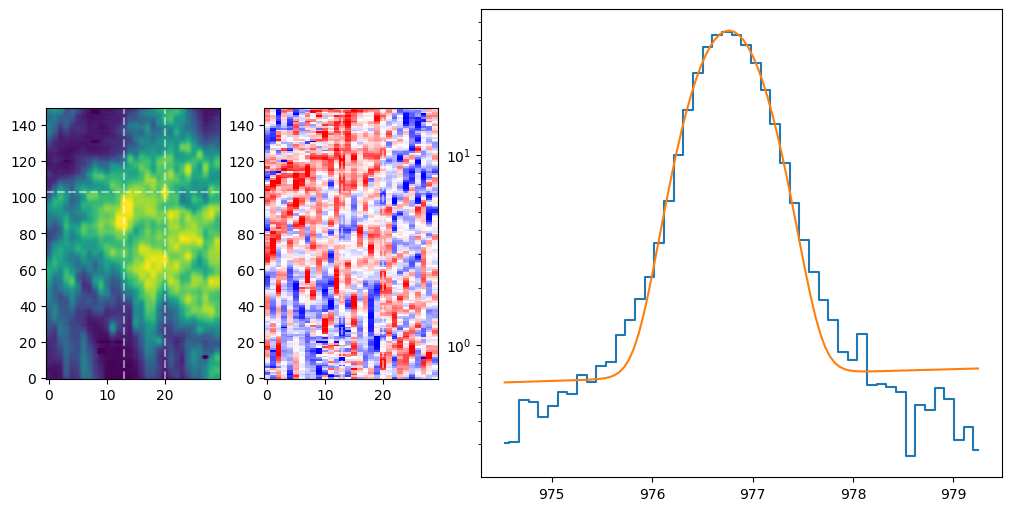

In [45]:
CIII_test_index = 353, 20
fig, (ax1,ax2,ax3) = plt.subplots(1,3, figsize=(10,5),layout="constrained",
                            gridspec_kw={'width_ratios': [1,1,3]})
ax1.imshow(CIII_977_fit_int[250:400,:], origin='lower',
           norm=ImageNormalize(vmin=np.nanpercentile(CIII_977_fit_int, 1),
                               vmax=np.nanpercentile(CIII_977_fit_int, 99.9),
                               stretch=AsinhStretch()), aspect=cdelt2/cdelt1)

ax2.imshow((CIII_977_fit_wvl - np.nanmedian(CIII_977_fit_wvl, axis=0)[np.newaxis,:])[250:400,:], origin='lower',
              norm=ImageNormalize(vmin=-30/3e5*977,
                                  vmax=30/3e5*977), aspect=cdelt2/cdelt1, cmap="bwr",
                                  interpolation='none')

ax3.step(CIII_977_wvl, CIII_977_data_all[:,CIII_test_index[0],CIII_test_index[1]], where='mid')
ax3.plot(np.linspace(CIII_977_wvl[0], CIII_977_wvl[-1], 100),
         func_CIII_977(np.linspace(CIII_977_wvl[0], CIII_977_wvl[-1], 100),
         CIII_977_fit_wvl[*CIII_test_index],
         CIII_977_fit_int[*CIII_test_index],
         CIII_977_fit_wid[*CIII_test_index],
         CIII_977_fit_a[*CIII_test_index],
         CIII_977_fit_b[*CIII_test_index]))
    

ax3.set_yscale("log")
for ax_ in (ax1,ax2):
    ax_.axvline(20, color='w', linestyle='--', alpha=0.5)
    ax_.axvline(13, color='w', linestyle='--', alpha=0.5)
    ax_.axhline(CIII_test_index[0]-250, color='w', linestyle='--', alpha=0.5)

In [46]:
def func_CIII_977_dg(x, wvl_977, int_977, wid_977, a, b, alpha, beta):
    return gaussian(x, wvl_977, int_977, wid_977) + \
           gaussian(x, wvl_977, int_977*alpha, wid_977*beta) + \
           a*x + b

In [47]:
CIII_977_dg_fit_int = np.zeros(CIII_977_data_all.shape[1:])
CIII_977_dg_fit_wvl = np.zeros(CIII_977_data_all.shape[1:])
CIII_977_dg_fit_wid = np.zeros(CIII_977_data_all.shape[1:])
CIII_977_dg_fit_a = np.zeros(CIII_977_data_all.shape[1:])
CIII_977_dg_fit_b = np.zeros(CIII_977_data_all.shape[1:])
CIII_977_dg_fit_alpha = np.zeros(CIII_977_data_all.shape[1:])
CIII_977_dg_fit_beta = np.zeros(CIII_977_data_all.shape[1:])

for i in range(CIII_977_data_all.shape[1]):
    for j in range(CIII_977_data_all.shape[2]):
        try:
            popt, pcov = curve_fit(func_CIII_977_dg, CIII_977_wvl, CIII_977_data_all[:,i,j], 
                                   p0=[CIII_977_wvl[np.argmax(CIII_977_data_all[:,i,j])],
                                   np.argmax(CIII_977_data_all[:,i,j]), 0.8,
                                   0, 0, 0.05, 2])
            CIII_977_dg_fit_int[i,j] = popt[1]
            CIII_977_dg_fit_wvl[i,j] = popt[0]
            CIII_977_dg_fit_wid[i,j] = popt[2]
            CIII_977_dg_fit_a[i,j] = popt[3]
            CIII_977_dg_fit_b[i,j] = popt[4]
            CIII_977_dg_fit_alpha[i,j] = popt[5]
            CIII_977_dg_fit_beta[i,j] = popt[6]
        except:
            pass

/scratch/tmp.25099103.zhuyin/ipykernel_667000/30964517.py:12: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(func_CIII_977_dg, CIII_977_wvl, CIII_977_data_all[:,i,j],


976.7649959137094 31.737897652482825 0.6878642372291627 0.05254096027773121 -51.140330506385396 -0.12226419528986276 -3.5034930853000352


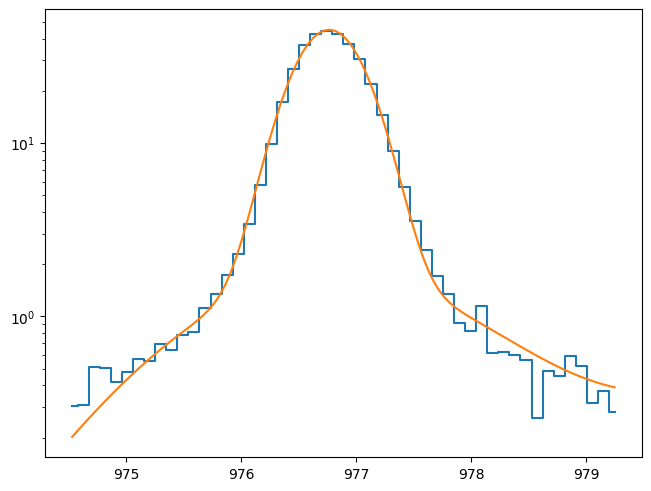

In [48]:
fig, ax = plt.subplots(layout="constrained")
ax.step(CIII_977_wvl, CIII_977_data_all[:,CIII_test_index[0],CIII_test_index[1]], where='mid')
ax.plot(np.linspace(CIII_977_wvl[0], CIII_977_wvl[-1], 100),
         func_CIII_977_dg(np.linspace(CIII_977_wvl[0], CIII_977_wvl[-1], 100),
         CIII_977_dg_fit_wvl[*CIII_test_index],
         CIII_977_dg_fit_int[*CIII_test_index],
         CIII_977_dg_fit_wid[*CIII_test_index],
         CIII_977_dg_fit_a[*CIII_test_index],
         CIII_977_dg_fit_b[*CIII_test_index],
         CIII_977_dg_fit_alpha[*CIII_test_index],
         CIII_977_dg_fit_beta[*CIII_test_index]))
ax.set_yscale("log")
print(   CIII_977_dg_fit_wvl[*CIII_test_index],
         CIII_977_dg_fit_int[*CIII_test_index],
         CIII_977_dg_fit_wid[*CIII_test_index],
         CIII_977_dg_fit_a[*CIII_test_index],
         CIII_977_dg_fit_b[*CIII_test_index],
         CIII_977_dg_fit_alpha[*CIII_test_index],
         CIII_977_dg_fit_beta[*CIII_test_index])

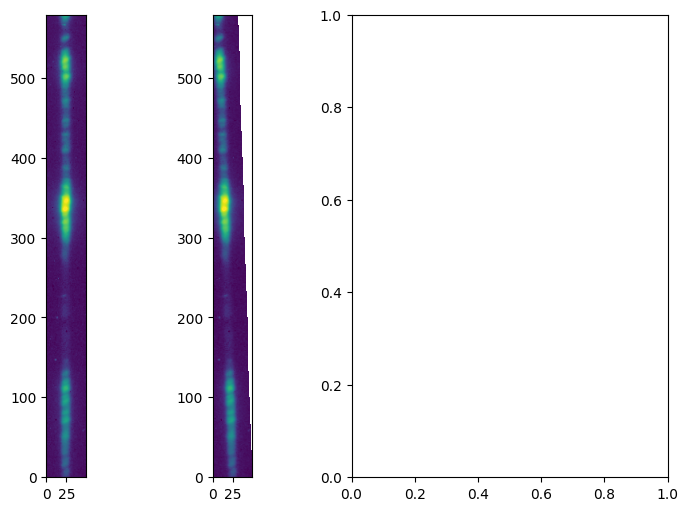

In [50]:
def skew_test(skew_factor=-0.075, CIII_977_data_all = CIII_977_data_all,
                CIII_977_wvl=CIII_977_fit_wvl):

    CIII_977_data_skew = np.zeros_like(CIII_977_data_all)
    la, ya = np.indices(CIII_977_data_all.shape[:2])
    la = la + skew_factor*ya

    for ii in range(CIII_977_data_all.shape[2]):
        rgi = RegularGridInterpolator((np.arange(CIII_977_data_all.shape[0]),np.arange(CIII_977_data_all.shape[1])),CIII_977_data_all[:,:,ii],
        bounds_error=False)
        CIII_977_data_skew[:,:,ii] = rgi((la, ya))
    
    fig, (ax1,ax2,ax3) = plt.subplots(1,3,figsize=(7,5),layout="constrained",
                            gridspec_kw={"width_ratios":[1,1,2]})
    
    ax1.imshow(CIII_977_data_all[:,:,13].T, origin="lower",
                norm=ImageNormalize(vmin=np.nanpercentile(CIII_977_data_all[:,:,13], 0.1),
                                    vmax=np.nanpercentile(CIII_977_data_all[:,:,13], 99.9),
                                    stretch=AsinhStretch(0.05)))
    ax2.imshow(CIII_977_data_skew[:,:,13].T, origin="lower",
                    norm=ImageNormalize(vmin=np.nanpercentile(CIII_977_data_skew[:,:,13], 0.1),
                                    vmax=np.nanpercentile(CIII_977_data_skew[:,:,13], 99.9),
                                    stretch=AsinhStretch(0.05)))

skew_test(0.03)


In [51]:
NIV_765_wvl = sw_wvl_list[0][695:730]
NIV_765_data_all = sw_data[695:730,210:790,:]

In [55]:
def func_NIV_765(x, wvl_765, int_765, wid_765, a, b):
    return gaussian(x, wvl_765, int_765, wid_765) + \
           a*x + b

In [57]:
NIV_765_fit_int = np.zeros(NIV_765_data_all.shape[1:])
NIV_765_fit_wvl = np.zeros(NIV_765_data_all.shape[1:])
NIV_765_fit_wid = np.zeros(NIV_765_data_all.shape[1:])
NIV_765_fit_a = np.zeros(NIV_765_data_all.shape[1:])
NIV_765_fit_b = np.zeros(NIV_765_data_all.shape[1:])

for i in range(NIV_765_data_all.shape[1]):
    for j in range(NIV_765_data_all.shape[2]):
        try:
            popt, pcov = curve_fit(func_NIV_765, NIV_765_wvl, NIV_765_data_all[:,i,j], 
                                    p0=[NIV_765_wvl[np.argmax(NIV_765_data_all[:,i,j])],
                                    np.argmax(NIV_765_data_all[:,i,j]), 0.8,
                                    0, 0])
            NIV_765_fit_int[i,j] = popt[1]
            NIV_765_fit_wvl[i,j] = popt[0]
            NIV_765_fit_wid[i,j] = popt[2]
            NIV_765_fit_a[i,j] = popt[3]
            NIV_765_fit_b[i,j] = popt[4]
        except:
            pass

/scratch/tmp.25099103.zhuyin/ipykernel_667000/3009267631.py:10: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(func_NIV_765, NIV_765_wvl, NIV_765_data_all[:,i,j],


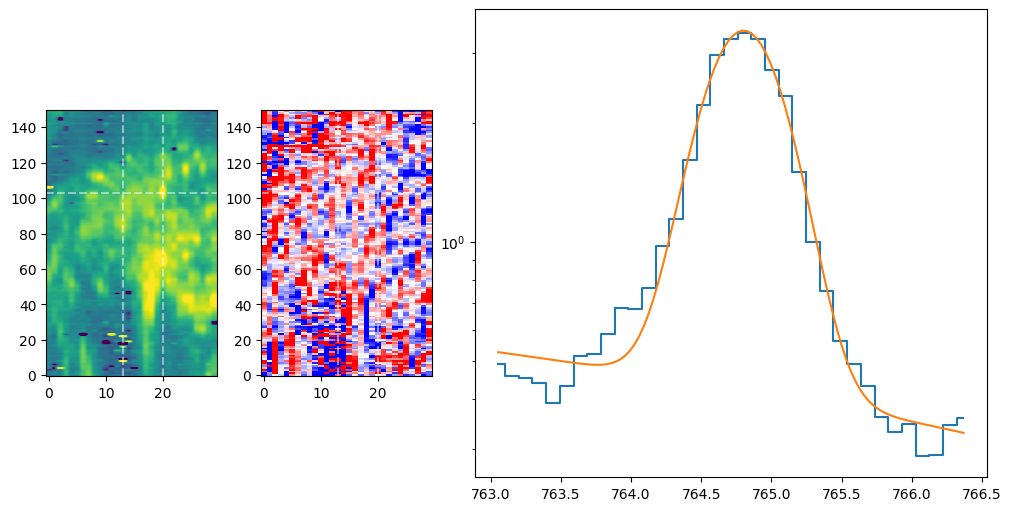

In [59]:
CIII_test_index = 353, 20
fig, (ax1,ax2,ax3) = plt.subplots(1,3, figsize=(10,5),layout="constrained",
                            gridspec_kw={'width_ratios': [1,1,3]})
ax1.imshow(NIV_765_fit_int[250:400,:], origin='lower',
           norm=ImageNormalize(vmin=np.nanpercentile(NIV_765_fit_int, 1),
                               vmax=np.nanpercentile(NIV_765_fit_int, 99.5),
                               stretch=AsinhStretch()), aspect=cdelt2/cdelt1)

ax2.imshow((NIV_765_fit_wvl - np.nanmedian(NIV_765_fit_wvl, axis=0)[np.newaxis,:])[250:400,:], origin='lower',
              norm=ImageNormalize(vmin=-30/3e5*977,
                                  vmax=30/3e5*977), aspect=cdelt2/cdelt1, cmap="bwr",
                                  interpolation='none')

ax3.step(NIV_765_wvl, NIV_765_data_all[:,CIII_test_index[0],CIII_test_index[1]], where='mid')
ax3.plot(np.linspace(NIV_765_wvl[0], NIV_765_wvl[-1], 100),
         func_NIV_765(np.linspace(NIV_765_wvl[0], NIV_765_wvl[-1], 100),
         NIV_765_fit_wvl[*CIII_test_index],
         NIV_765_fit_int[*CIII_test_index],
         NIV_765_fit_wid[*CIII_test_index],
         NIV_765_fit_a[*CIII_test_index],
         NIV_765_fit_b[*CIII_test_index]))
    

ax3.set_yscale("log")
for ax_ in (ax1,ax2):
    ax_.axvline(20, color='w', linestyle='--', alpha=0.5)
    ax_.axvline(13, color='w', linestyle='--', alpha=0.5)
    ax_.axhline(CIII_test_index[0]-250, color='w', linestyle='--', alpha=0.5)